In [ ]:
import jax 
import jax.numpy as jnp
from flax import linen as nn

def get_layers(neurons: tuple[int, ...]):

    if not neurons:
        return None
    
    layers = []
    for n in neurons:
        layers.append(
            nn.Dense(n)
        )
    return tuple(layers)

def forward(h, last_linear, layers):
    if not layers: 
        return h
    
    for layer in layers[:-1]:
        h = nn.relu(layer(h))
    
    final_layer = layers[-1]
    h = final_layer(h)
    
    return h if last_linear else nn.relu(h)   

class DeModelMlp(nn.Module):
    
    out: tuple[int, ...]
    delegation: tuple[int, ...]
    body: tuple[int, ...] | None = None
    
    def setup(self):
        self.body_layers = get_layers(self.body)
        self.out_layers = get_layers(self.out)
        self.delegation_layers = get_layers(self.delegation)

    def __call__(self, x: jax.Array):
        h = x
        h_body = forward(h, last_linear=False, layers=self.body_layers)
        y = forward(h_body, last_linear=True, layers=self.out_layers)
        d = forward(h_body, last_linear=True, layers=self.delegation_layers)
        return y, d

class LeMlp(nn.Module):
    n_models: int
    out: tuple[int, ...]
    delegation: tuple[int, ...]
    body: tuple[int, ...] | None = None

    def setup(self):
        
        assert self.delegation[-1] == self.n_models, "Out of delegation needs to equal to n_models"

        VmappedDeModelMlp = nn.vmap(
            DeModelMlp,
            variable_axes={'params': 0},
            split_rngs={'params': True}, # Vmap over different models
            in_axes=None, # Do not vmap over batch elements
            axis_size=self.n_models,
            out_axes=1 # Stack the model outputs to axis=1
        )
        
        self.ensemble = VmappedDeModelMlp(
            out=self.out, 
            delegation=self.delegation, 
            body=self.body
        )

    def __call__(self, x: jax.Array):
        return self.ensemble(x)

In [24]:

k1, k2 = jax.random.split(jax.random.key(123))

x = jax.random.uniform(k1, (32, 3))

e = LeMlp(
    n_models=9,
    body=(10,),
    out=(10, 5),
    delegation=(9,)  # Added trailing comma
)
params = e.init(k2, x[[0], :])["params"]

out = e.apply({"params": params}, x)  # Passed x to apply


In [32]:
out[1][2]

Array([[ 2.43651062e-01,  3.25399846e-01,  2.45215982e-01,
        -1.51339337e-01,  4.47084531e-02,  3.19936275e-02,
         7.51890689e-02,  1.29513144e-01, -3.07852268e-01],
       [ 3.33973497e-01,  5.50473273e-01,  2.77067870e-01,
        -1.89043671e-01,  3.80693711e-02,  5.58309406e-02,
         1.33681610e-01,  2.45153368e-01, -5.53084016e-01],
       [ 9.58338976e-02,  8.04909527e-01,  8.64893198e-04,
         2.94821233e-01,  1.72077790e-02,  2.05883801e-01,
        -2.50082016e-02,  1.47514701e-01, -7.04494834e-01],
       [ 8.30525994e-01,  1.20956469e+00,  7.27195144e-01,
        -3.76859426e-01,  1.56129956e-01,  3.66317153e-01,
         4.23974037e-01,  2.97265410e-01, -1.13230610e+00],
       [ 1.18144810e-01,  1.08232164e+00, -2.14539468e-02,
         5.73526084e-01,  8.47710967e-02,  5.87218106e-01,
         8.55676234e-02, -1.14739358e-01, -8.58933806e-01],
       [ 6.95456386e-01,  1.05535829e+00,  5.87647915e-01,
        -3.60512733e-01,  1.10603638e-01,  2.384294

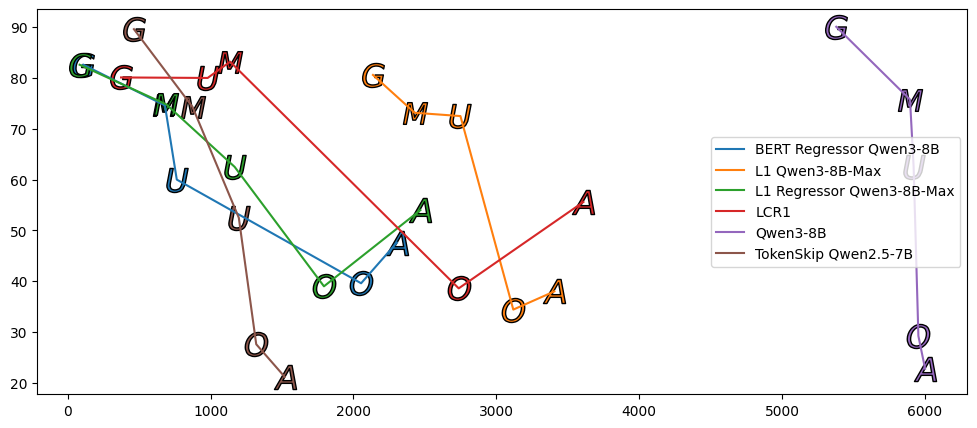

In [36]:
from matplotlib import pyplot as plt
import pandas as pd

df = pd.read_csv("./model_performance_data.csv")

df = pd.wide_to_long(
    df, 
    stubnames=['Accuracy', 'AvgTokens'], 
    i=['Category', 'Method'], 
    j='Benchmark', 
    sep='_', 
    suffix='.*'
).reset_index()


fig, ax = plt.subplots(figsize=(12, 5))

for method, g in df.groupby("Method"):
    g = g.sort_values("AvgTokens")

    # plot line and capture color
    line, = ax.plot(g["AvgTokens"], g["Accuracy"], label=method)

    for _, row in g.iterrows():

        letter = row["Benchmark"]
        if letter == "AMC":
            letter = "U"
        else:
            letter = letter[0]
        # scatter using the same color as the line
        ax.scatter(
            row["AvgTokens"],
            row["Accuracy"],
            marker=f"${letter}$",
            s=300,
            facecolors=line.get_color(),
            edgecolors="black",
            linewidths=1
        )

ax.legend()

In [27]:
df.columns

Index(['Category', 'Method', 'Benchmark', 'Accuracy', 'AvgTokens'], dtype='str')

In [29]:
import pandas as pd

def pareto_frontier(df):
    df = df.sort_values("AvgTokens")
    frontier = []

    best_acc = -float("inf")

    for _, row in df.iterrows():
        if row["Accuracy"] > best_acc:
            frontier.append(True)
            best_acc = row["Accuracy"]
        else:
            frontier.append(False)

    df = df.copy()
    df["Pareto"] = frontier
    return df


result = (
    df.groupby("Benchmark", group_keys=False)
      .apply(pareto_frontier)
)

result

,Category,Method,Accuracy,AvgTokens,Pareto
19,Other Token Reduction Methods,TokenSkip Qwen2.5-7B,21.20,1518.8,True
9,Our Methods,BERT Regressor Qwen3-8B,47.60,2304.0,True
4,Our Methods,L1 Regressor Qwen3-8B-Max,54.00,2469.0,True
24,Base Models,L1 Qwen3-8B-Max,38.00,3406.5,False
14,Other Token Reduction Methods,LCR1,55.60,3609.7,True
29,Base Models,Qwen3-8B,22.80,6000.8,False
8,Our Methods,BERT Regressor Qwen3-8B,60.00,764.0,True
13,Other Token Reduction Methods,LCR1,80.00,980.0,True
3,Our Methods,L1 Regressor Qwen3-8B-Max,62.50,1169.0,False
18,Other Token Reduction Methods,TokenSkip Qwen2.5-7B,52.50,1198.0,False


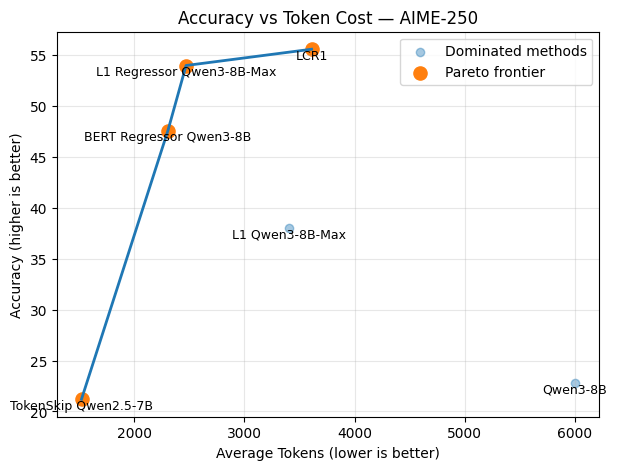

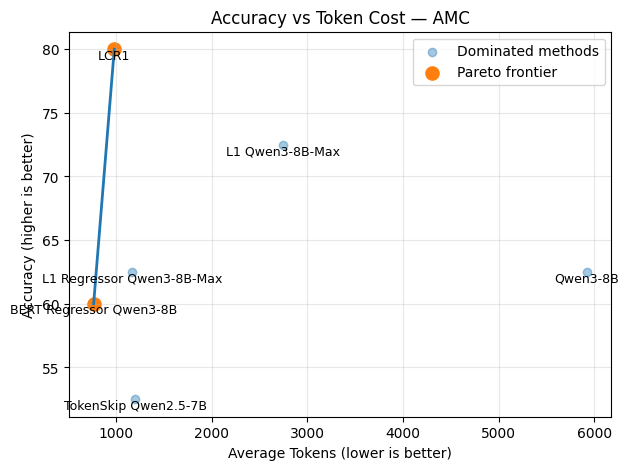

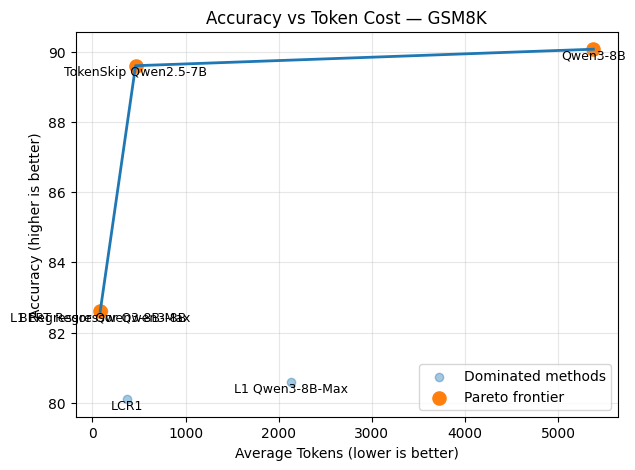

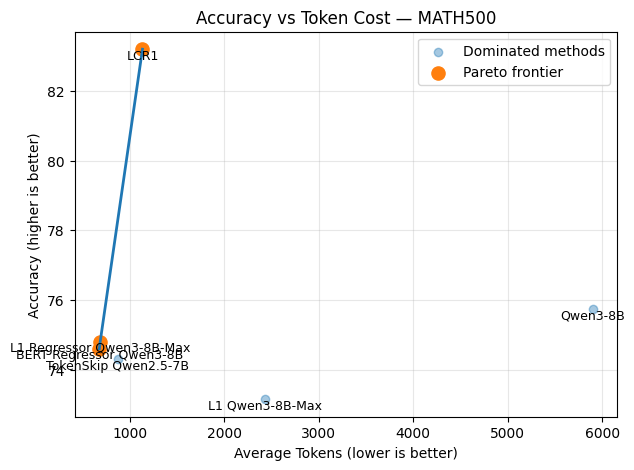

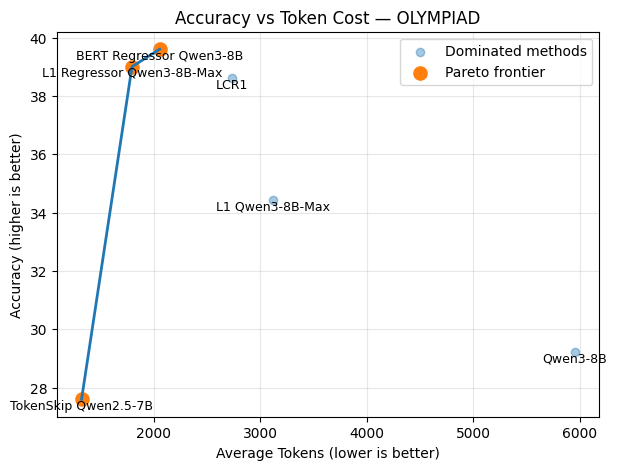

In [53]:
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

def pareto_frontier(df):
    df = df.sort_values("AvgTokens")
    frontier = []
    best_acc = -float("inf")

    for _, row in df.iterrows():
        if row["Accuracy"] > best_acc:
            frontier.append(True)
            best_acc = row["Accuracy"]
        else:
            frontier.append(False)

    df = df.copy()
    df["Pareto"] = frontier
    return df




par = defaultdict(lambda: 0)

for bench, sub in df.groupby("Benchmark"):

    pf = pareto_frontier(sub)
    now = pf[["Method", "Pareto"]].set_index("Method")["Pareto"].to_dict()
    for m, p in now.items():
        par[m] += 1 if p else 0
        
    frontier = pf[pf["Pareto"]].sort_values("AvgTokens")
    dominated = pf[~pf["Pareto"]]

    plt.figure(figsize=(7,5))

    # dominated points
    plt.scatter(
        dominated["AvgTokens"],
        dominated["Accuracy"],
        alpha=0.4,
        label="Dominated methods"
    )

    # Pareto points
    plt.scatter(
        frontier["AvgTokens"],
        frontier["Accuracy"],
        s=90,
        label="Pareto frontier"
    )

    # frontier line
    plt.plot(
        frontier["AvgTokens"],
        frontier["Accuracy"],
        linewidth=2
    )

    # annotate methods
    for _, r in pf.iterrows():
        plt.text(
            r["AvgTokens"],
            r["Accuracy"],
            r["Method"],
            fontsize=9,
            ha="center",
            va="top"
        )

    plt.xlabel("Average Tokens (lower is better)")
    plt.ylabel("Accuracy (higher is better)")
    plt.title(f"Accuracy vs Token Cost — {bench}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

Text(0.5, 0, '#Pareto optimal')

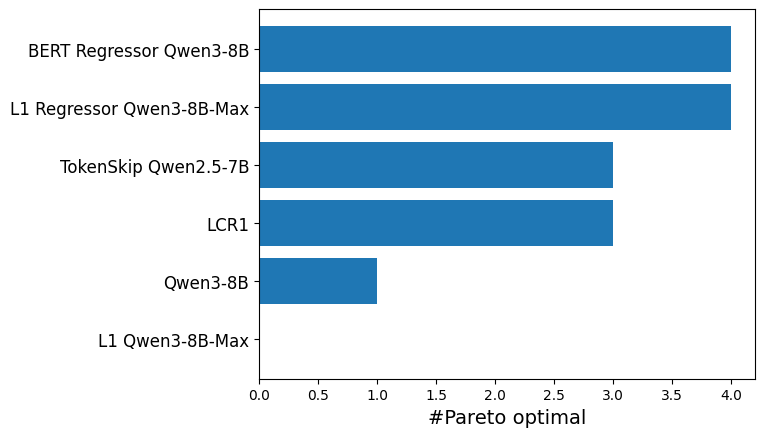

In [79]:
import numpy as np

x = []
y = []

for m, p in par.items():
    x.append(m)
    y.append(p)

x = np.array(x)
y = np.array(y)

si = np.argsort(y)
x = x[si]
y = y[si]

fig, ax = plt.subplots()

ax.barh(np.arange(len(x)), y)
ax.set_yticks(np.arange(len(x)), x, rotation=0, fontsize=12)
ax.set_xlabel("#Pareto optimal", fontsize=14)

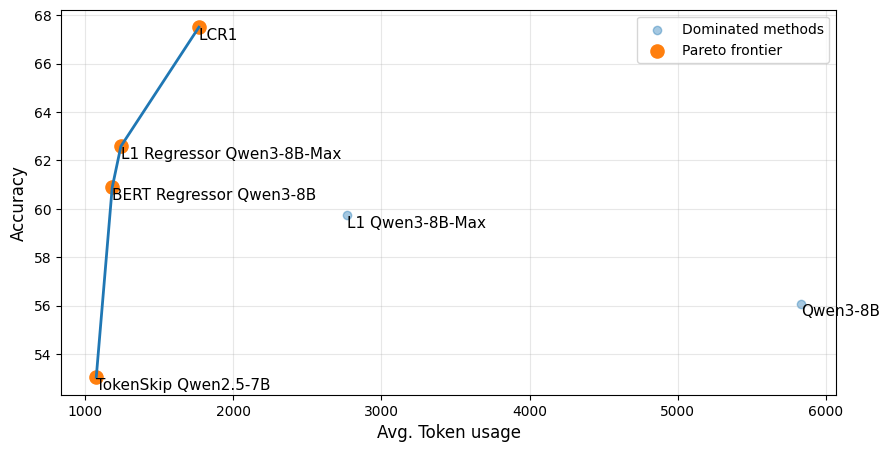

In [71]:
pf = pareto_frontier(df.groupby("Method", as_index=False).agg({"Accuracy": "mean", "AvgTokens": "mean"}))
frontier = pf[pf["Pareto"]].sort_values("AvgTokens")
dominated = pf[~pf["Pareto"]]

plt.figure(figsize=(10,5))

# dominated points
plt.scatter(
    dominated["AvgTokens"],
    dominated["Accuracy"],
    alpha=0.4,
    label="Dominated methods"
)

# Pareto points
plt.scatter(
    frontier["AvgTokens"],
    frontier["Accuracy"],
    s=90,
    label="Pareto frontier"
)

# frontier line
plt.plot(
    frontier["AvgTokens"],
    frontier["Accuracy"],
    linewidth=2
)

# annotate methods
for _, r in pf.iterrows():
    plt.text(
        r["AvgTokens"],
        r["Accuracy"],
        r["Method"],
        fontsize=11,
        ha="left",
        va="top"
    )

plt.xlabel("Avg. Token usage", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

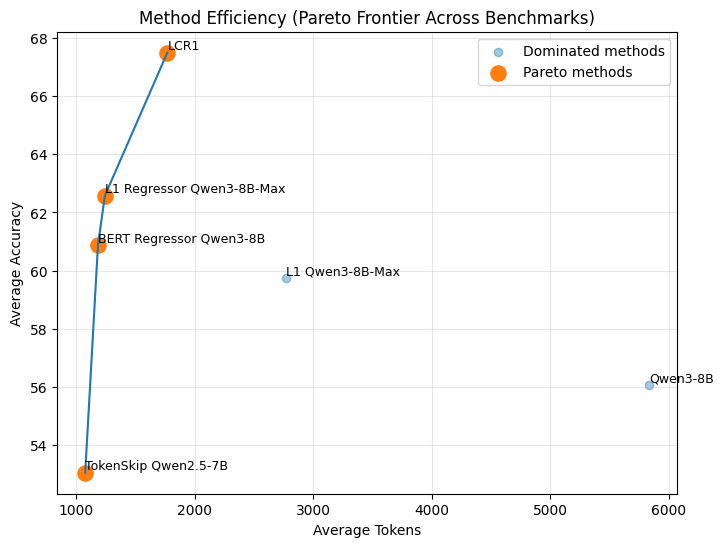

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate across benchmarks
df_method = (
    df.groupby("Method", as_index=False)
      .agg(
          Accuracy=("Accuracy", "mean"),
          AvgTokens=("AvgTokens", "mean")
      )
)

# Pareto frontier
df_method = df_method.sort_values("AvgTokens").copy()

best_acc = -float("inf")
pareto = []

for _, r in df_method.iterrows():
    if r["Accuracy"] > best_acc:
        pareto.append(True)
        best_acc = r["Accuracy"]
    else:
        pareto.append(False)

df_method["Pareto"] = pareto


plt.figure(figsize=(8,6))

dominated = df_method[~df_method["Pareto"]]
frontier = df_method[df_method["Pareto"]]

plt.scatter(
    dominated["AvgTokens"],
    dominated["Accuracy"],
    alpha=0.4,
    label="Dominated methods"
)

plt.scatter(
    frontier["AvgTokens"],
    frontier["Accuracy"],
    s=120,
    label="Pareto methods"
)

# frontier line
frontier = frontier.sort_values("AvgTokens")
plt.plot(frontier["AvgTokens"], frontier["Accuracy"])

# label methods
for _, r in df_method.iterrows():
    plt.text(
        r["AvgTokens"],
        r["Accuracy"],
        r["Method"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.xlabel("Average Tokens")
plt.ylabel("Average Accuracy")
plt.title("Method Efficiency (Pareto Frontier Across Benchmarks)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()